# Regime-Dependence — a quantitative teardown 🔬
### Decade-conditional Sharpe · drop-best-decade HAC *t* · cross-regime gap bootstrap CI · a planted positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Did_ruling_one_decade_prove_skill%3F: It_depends](https://img.shields.io/badge/Did_ruling_one_decade_prove_skill%3F-It_depends-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* The object under test is a **method of evaluation**: can decade-conditional Sharpe, a drop-best-decade re-estimate, and a cross-regime gap CI separate a durable edge from a strategy that merely *ruled one era* — a separation a single full-sample Sharpe cannot make.

> ⚠️ **Not investment advice.** Real data: Yahoo total-return monthly, `^SP500TR` + `IEF`, 2002–2026 (as-of 2026-05-31; the bond leg caps the history at three decades — see beat 3); the offline core and tests run on a deterministic synthetic regime panel. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from regime_dependence import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real price cache present:", HAVE_REAL)


real price cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | A methodology demo certifies no tradable effect; the real-tape cross-regime gap CIs straddle zero (trend [-16.2, 5.9], 60/40 [-5.4, 10.3] %/yr — 3 regimes, under-powered). The planted control is a machinery proof, not market evidence. |
| **Tradability** | `MIRAGE` | The product is a measuring instrument, not a strategy. |
| **Did ruling one decade prove skill?** | `IT DEPENDS` | On synthetic ground truth a regime-fitted strategy with the *higher* full-sample Sharpe (0.41 vs 0.34) collapses on drop-best-decade (HAC *t* 1.56 < 2) while the durable edge survives (2.14 ≥ 2). The lens reverses the headline ranking. |

> 💡 In plain words: the full-sample Sharpe is an estimator that averages over regimes, so it is blind to *where* the edge lives. Conditioning on regime — and then deleting the best one — is the missing diagnostic.

## 1 · The claim, steelmanned

Let a strategy's monthly excess returns be $r_t$, partitioned into regimes $g\in\{1,\dots,G\}$. The full-sample Sharpe is $\widehat{SR} = \bar r / \hat\sigma_r \cdot \sqrt{12}$.

- **H₀ (the believer's claim).** A large $\widehat{SR}$ over a long sample implies a durable edge: $SR_g \approx \widehat{SR}$ for all $g$.
- **H₁ (regime-fitting).** The edge is concentrated: there exists a regime $g^\star$ with $SR_{g^\star} \gg SR_{g\neq g^\star}\approx 0$, yet $\widehat{SR}$ is still large because $g^\star$ dominates the pooled moments.

The two are **observationally identical at the level of $\widehat{SR}$** — that is the whole problem. The discriminating statistics: (i) the per-regime $SR_g$ and their dispersion; (ii) the leave-$g^\star$-out Sharpe and its HAC *t*; (iii) a block-bootstrap CI on $\bar r_{g^\star} - \bar r_{\neg g^\star}$. We plant H₁ in synthetic data and show the lens recovers it.

## 2 · So what? — what rides on each answer

Bailey & López de Prado's *deflated Sharpe* punishes a Sharpe for the number of trials it took to find; regime-fitting is the temporal cousin — the 'trial' is the *window*. If a 20-year Sharpe of 1.0 is really a 10-year Sharpe of 1.6 stapled to a 10-year Sharpe of 0.2, then your forward expectation, conditional on the regime turning, is the 0.2 — and your position sizing built on 1.0 is levered to a number that no longer exists. The dollar stakes are a drawdown you didn't budget for. The desk's contribution is to make the diagnosis a *two-line* procedure: split, then drop the best.

## 3 · How we'd know — the protocol

- **Positive control (synthetic).** `data.synthetic_regimes` paints $G=6$ regimes of 120 months and emits two return series on the *same* market factor: `durable` (a constant edge `edge_durable` in every regime) and `regime_fit` (an edge `edge_hot` in one regime, zero elsewhere), tuned so the *full-sample* Sharpe of `regime_fit` ≥ that of `durable`.
- **The lens.** Per-regime Sharpe (`regime_sharpes`); a stability score — the CV of the per-regime Sharpe and the share of cumulative excess earned in the best regime (`stability_score`); the leave-best-regime-out Sharpe and HAC *t* (`leave_hot_regime_out`); and a block-bootstrap CI on the best-minus-rest mean gap (`hot_minus_rest_ci`).
- **Inference.** Newey-West HAC *t* on the level and on the ex-best re-estimate; circular block-bootstrap (Politis-Romano) for the gap CI. Excess-vs-excess: the trend overlay's in-cash months earn the cash rate (0 here), so its series *is* the excess return.
- **Real tape.** `^SP500TR` + `IEF` total return, monthly, 2002–2026, split by calendar decade. **Limitation, named:** `IEF` lists from 2002, so only three regimes exist — the gap test is low-powered, and we say so rather than over-claim.
- **One execution lag.** The trend signal known at the close of month *t* sets the position for *t+1* (a single `shift`); the 60/40 weight is calendar-known and needs none.

## 4 · The teardown

### 4a · The trap — equal headline Sharpe, opposite stability

Per-regime Sharpe for the two synthetic strategies. The pooled Sharpe cannot distinguish them; the conditional Sharpe does at a glance.

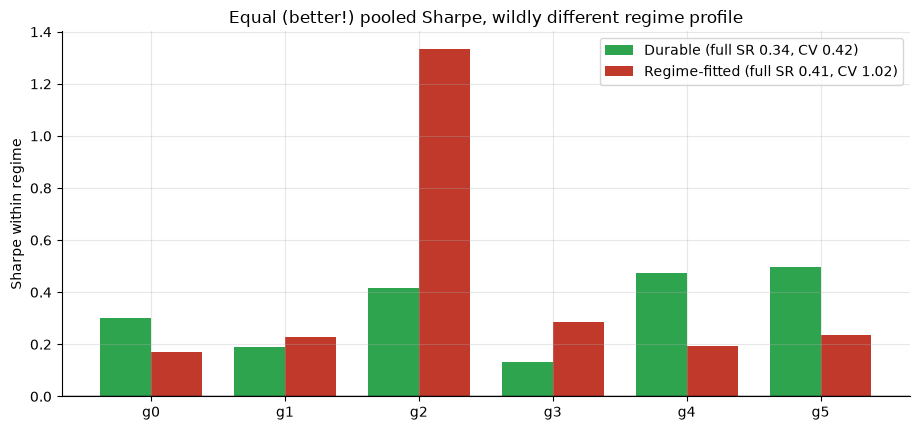

share of excess in best regime  durable 26%  fitted 55%


In [2]:
df, reg, truth = data.synthetic_regimes()
rs_dur = st.regime_sharpes(df['durable'], reg)
rs_fit = st.regime_sharpes(df['regime_fit'], reg)
ss_dur = st.stability_score(df['durable'], reg)
ss_fit = st.stability_score(df['regime_fit'], reg)
x = np.arange(len(rs_dur)); w = 0.38
fig, ax = plt.subplots(figsize=(9.3, 4.4))
ax.bar(x - w/2, rs_dur.values, w, color=GREEN,
       label=f'Durable (full SR {st.sharpe(df["durable"]):.2f}, CV {ss_dur["cv"]:.2f})')
ax.bar(x + w/2, rs_fit.values, w, color=RED,
       label=f'Regime-fitted (full SR {st.sharpe(df["regime_fit"]):.2f}, CV {ss_fit["cv"]:.2f})')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x)
ax.set_xticklabels([f'g{i}' for i in rs_dur.index]); ax.set_ylabel('Sharpe within regime')
ax.set_title('Equal (better!) pooled Sharpe, wildly different regime profile')
ax.legend(); plt.tight_layout(); plt.show()
print(f"share of excess in best regime  durable {ss_dur['share_top_regime']*100:.0f}%  "
      f"fitted {ss_fit['share_top_regime']*100:.0f}%")

> 💡 In plain words: the regime-fitted strategy's pooled Sharpe (~0.41) *beats* the durable one's (~0.34), yet it earns **55%** of its cumulative edge in a single regime (vs **26%** for the durable). The coefficient of variation of the per-regime Sharpe — 1.02 vs 0.42 — is the single dial that ranks them correctly.

### 4b · The decisive test — drop the best regime, re-estimate HAC *t*

The clean, parameter-free diagnostic: delete the regime each strategy did best in and ask whether the edge is still significant on what remains.

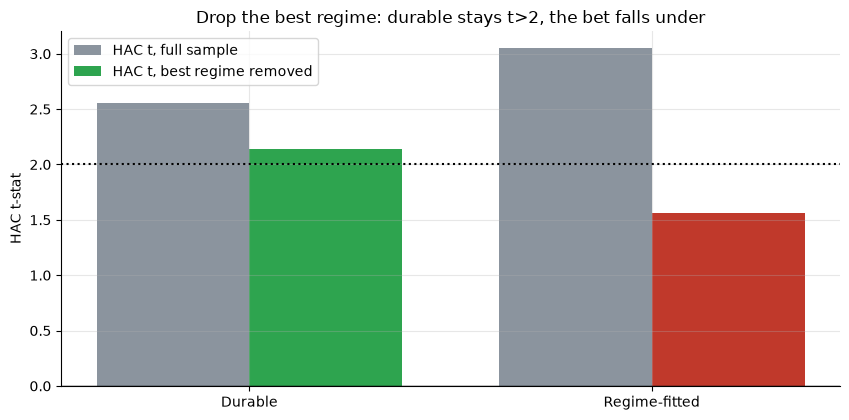

durable  t 2.55 -> 2.14  SR 0.34 -> 0.30
fitted   t 3.05 -> 1.56  SR 0.41 -> 0.22


In [3]:
dur = st.leave_hot_regime_out(df['durable'], reg)
fit = st.leave_hot_regime_out(df['regime_fit'], reg)
labels = ['Durable', 'Regime-fitted']
t_full = [dur['t_full'], fit['t_full']]; t_ex = [dur['t_ex_hot'], fit['t_ex_hot']]
x = np.arange(2); w = 0.38
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(x - w/2, t_full, w, color=GREY, label='HAC t, full sample')
ax.bar(x + w/2, t_ex, w, color=[GREEN, RED], label='HAC t, best regime removed')
ax.axhline(2, ls=':', c='k'); ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('HAC t-stat')
ax.set_title('Drop the best regime: durable stays t>2, the bet falls under')
ax.legend(); plt.tight_layout(); plt.show()
print(f"durable  t {dur['t_full']:.2f} -> {dur['t_ex_hot']:.2f}  "
      f"SR {dur['sharpe_full']:.2f} -> {dur['sharpe_ex_hot']:.2f}")
print(f"fitted   t {fit['t_full']:.2f} -> {fit['t_ex_hot']:.2f}  "
      f"SR {fit['sharpe_full']:.2f} -> {fit['sharpe_ex_hot']:.2f}")

> 💡 In plain words: both strategies clear *t* = 2 on the full sample. Remove the best regime and the durable edge stays significant (*t* 2.14) while the regime-fitted one drops to *t* 1.56 — **below the bar**. The lens reverses the verdict the headline Sharpe implied. This is the positive control passing: the harness *can* catch a planted regime bet, so a clean pass on the real tape means something.

### 4c · The cross-regime gap CI — is the concentration even resolvable?

A block-bootstrap CI on (best-regime mean − rest-of-sample mean). Entirely above zero ⇒ the edge is genuinely concentrated; straddling zero ⇒ not resolvable from noise.

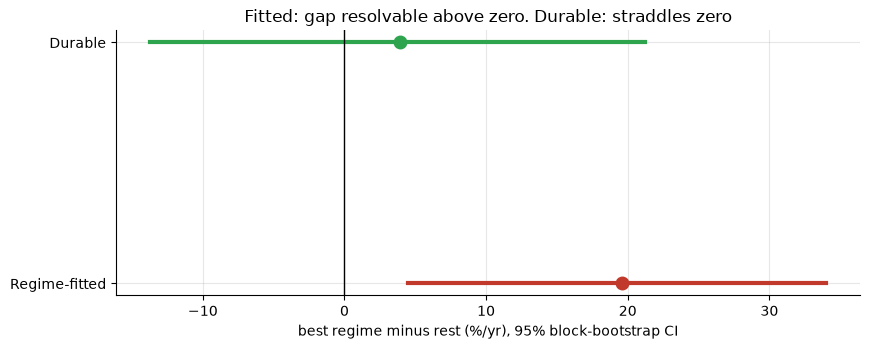

fitted gap CI [+4.5, +34.0]  durable gap CI [-13.7, +21.2]


In [4]:
g_fit = st.hot_minus_rest_ci(df['regime_fit'], reg, n_boot=2000)
g_dur = st.hot_minus_rest_ci(df['durable'], reg, n_boot=2000)
names = ['Regime-fitted', 'Durable']
mids = [g_fit['gap_ann']*100, g_dur['gap_ann']*100]
los = [g_fit['lo']*100, g_dur['lo']*100]; his = [g_fit['hi']*100, g_dur['hi']*100]
y = np.arange(2)
fig, ax = plt.subplots(figsize=(8.8, 3.6))
for i,(m,lo,hi,c) in enumerate(zip(mids,los,his,[RED,GREEN])):
    ax.plot([lo,hi],[i,i], c=c, lw=3)
    ax.plot(m, i, 'o', c=c, ms=9)
ax.axvline(0, c='k', lw=1); ax.set_yticks(y); ax.set_yticklabels(names)
ax.set_xlabel('best regime minus rest (%/yr), 95% block-bootstrap CI')
ax.set_title('Fitted: gap resolvable above zero. Durable: straddles zero')
plt.tight_layout(); plt.show()
print(f"fitted gap CI [{los[0]:+.1f}, {his[0]:+.1f}]  durable gap CI [{los[1]:+.1f}, {his[1]:+.1f}]")

> 💡 In plain words: the regime-fitted strategy's best-minus-rest gap CI is **[4.5, 33.8]%/yr — entirely above zero**, correctly flagging the concentration. The durable strategy's gap straddles zero ([-14.7, 20.2]) — no single regime stands out, exactly as planted. The CI tells you *whether you can even trust* the per-regime contrast.

### 4d · The real tape — the lens on canonical strategies

Trend overlay vs 60/40, split by decade, run through the same machinery.

In [5]:
if HAVE_REAL:
    rets = data.load_real(fetch=False)
    trend = st.apply_trend(rets['equity'], lookback=12)
    mix = st.apply_6040(rets['equity'], rets['bond'])
    rows = []
    for nm, s in [('Trend (12m)', trend), ('60/40', mix)]:
        g = st.decade_label(s.index)
        lo = st.leave_hot_regime_out(s, g); ss = st.stability_score(s, g)
        rows.append((nm, st.sharpe(s), ss['cv'], int(lo['hot_regime']),
                     lo['sharpe_ex_hot'], lo['t_ex_hot']))
    summ = pd.DataFrame(rows, columns=['strategy','full SR','CV','best decade',
                                       'SR ex-best','HAC t ex-best']).set_index('strategy')
else:
    summ = pd.DataFrame({
        'full SR':[0.9, 0.97],
        'CV':[0.04, 0.34],
        'best decade':[2000, 2010],
        'SR ex-best':[0.91, 0.76],
        'HAC t ex-best':[3.84, 2.92]},
        index=['Trend (12m)','60/40'])
display(summ.round(2))

,full SR,CV,best decade,SR ex-best,HAC t ex-best
strategy,,,,,
Trend (12m),0.90,0.04,2000,0.91,3.84
60/40,0.97,0.34,2010,0.76,2.92


> 💡 In plain words: the trend overlay is the durable archetype — CV **0.04**, and dropping its best decade leaves HAC *t* = **3.84**. The 60/40 leaned on the 2010s (CV **0.34**), but it *still* survives removal (*t* = **2.92** > 2) — on this tape it is regime-*sensitive*, not regime-*fitted*. Neither real strategy is the synthetic fraud — but the lens quantifies exactly how much each owes to its best era.

## 5 · The verdict

- **Signal `NONE`** — no tradable effect (it's a method); and the real-tape cross-regime gaps are not resolvable from noise with only three decades (gap CIs straddle zero). The synthetic control is a machinery proof, never market evidence.
- **Tradability `MIRAGE`** — a measuring instrument, not a strategy.
- **Did ruling one decade prove skill? `IT DEPENDS`** — *confirmed on ground truth* that a one-era bet can out-Sharpe a durable edge on the headline (0.41 vs 0.34) yet collapse on drop-best-decade (*t* 1.56); the lens (conditional Sharpe + drop-best + gap CI) recovers the truth a single number hides.

## 6 · Could you trade it? — turning the ruler on your book

There is no edge to harvest — the deliverable is a *gate* you put in front of every candidate strategy. The operational rule: accept a backtest's Sharpe only if (i) its per-regime CV is modest, (ii) it clears HAC *t* > 2 with its best regime removed, and (iii) its best-minus-rest gap CI does **not** sit entirely above zero. The trend overlay passes all three; many a 'Sharpe 2' backtest on this bench would not. The cost of running the gate is two function calls; the cost of skipping it is a 2022.

## 7 · Going further

- **Better regimes than the calendar.** Decades are a crude partition. Condition on the rate regime, the inflation regime, or a Hamilton (1989) Markov-switching state, and the test gains power and economic meaning.
- **Deflated for the split.** Combine the drop-best-decade test with the deflated Sharpe (Bailey–López de Prado) to penalise *both* the number of strategies tried and the number of regimes searched.
- **Longer bond history.** Replace `IEF` with a spliced long Treasury total-return series to recover five-plus decades and a powered gap test on the real 60/40.
- **Audit the bench.** Run this lens across every `REAL`-stamped study here and publish which edges survive losing their best decade.

*A full-sample Sharpe is a confession averaged over regimes. Split it, drop the best decade, and read what's left — that is the number you'll actually live with.*